<a href="https://colab.research.google.com/github/Kunalpatel-08/Banking_Term_deposit_classification/blob/main/MY_Copy_of_projectBank_loan_propensity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
project_id = 'lon-propensity-project'
!gcloud config set project {project_id}


[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

In [4]:
# Authenticated account
from google.colab import auth
auth.authenticate_user()

# Import the BigQuery library
from google.cloud import bigquery

# Create a BigQuery client
project_id = 'lon-propensity-project'
client = bigquery.Client(project=project_id)

# Query for data loading
query = """
SELECT *
FROM `lon-propensity-project.loan_propensity_dataset.customer_loan_data`
"""

# Load all rows into a dataframe
df = client.query(query).to_dataframe()

# Check for total rows loaded
print(f"Successfully loaded {len(df)} rows!")

Successfully loaded 11162 rows!


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,26,admin.,single,secondary,False,274,False,False,cellular,1,apr,351,3,-1,0,unknown,True
1,34,admin.,married,secondary,False,1474,False,False,cellular,2,apr,739,2,-1,0,unknown,True
2,32,admin.,single,secondary,False,471,False,True,cellular,2,apr,243,3,-1,0,unknown,True
3,48,admin.,divorced,secondary,False,4099,False,False,cellular,2,apr,397,2,-1,0,unknown,True
4,37,admin.,married,secondary,False,1207,True,False,telephone,6,apr,1353,2,138,2,success,True


In [6]:
# Create a copy
bank_df = df.copy()

In [7]:
# Renaming the Target Variable
bank_df.rename(columns={'deposit':'term_deposit'}, inplace=True)

In [8]:
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,26,admin.,single,secondary,False,274,False,False,cellular,1,apr,351,3,-1,0,unknown,True
1,34,admin.,married,secondary,False,1474,False,False,cellular,2,apr,739,2,-1,0,unknown,True
2,32,admin.,single,secondary,False,471,False,True,cellular,2,apr,243,3,-1,0,unknown,True
3,48,admin.,divorced,secondary,False,4099,False,False,cellular,2,apr,397,2,-1,0,unknown,True
4,37,admin.,married,secondary,False,1207,True,False,telephone,6,apr,1353,2,138,2,success,True


In [9]:
# Check the shape of dataset
print(f"Shape: {bank_df.shape}")

Shape: (11162, 17)


In [10]:
# Check for missing values in the dataframe
print(f"Missing values: {bank_df.isnull().sum()}")

Missing values: age             0
job             0
marital         0
education       0
default         0
balance         0
housing         0
loan            0
contact         0
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome        0
term_deposit    0
dtype: int64


In [11]:
# Dataset Overview
meta = pd.DataFrame({
    'dtype': bank_df.dtypes,
    'nulls': bank_df.isnull().sum(),
    'n_unique': bank_df.nunique(),
}).to_string()
print(meta)

                dtype  nulls  n_unique
age             Int64      0        76
job            object      0        12
marital        object      0         3
education      object      0         4
default       boolean      0         2
balance         Int64      0      3805
housing       boolean      0         2
loan          boolean      0         2
contact        object      0         3
day             Int64      0        31
month          object      0        12
duration        Int64      0      1428
campaign        Int64      0        36
pdays           Int64      0       472
previous        Int64      0        34
poutcome       object      0         4
term_deposit  boolean      0         2


In [12]:
# Check for duolicate values in dataset
print('\nDUPLICATES:', bank_df.duplicated().sum())


DUPLICATES: 0


In [13]:
bank_df['term_deposit'].value_counts()

,count
term_deposit,
False,5873
True,5289


In [14]:
display(bank_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
day,11162.0,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.0,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.0,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.0,58.0


/tmp/ipykernel_567/2750109150.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes']) # Changed False/True to clean text


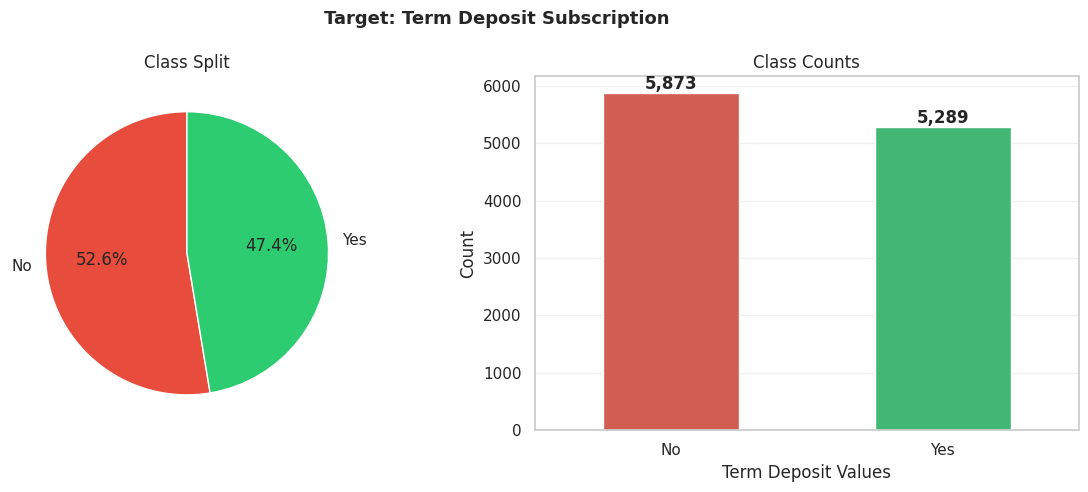

No: 52.6%  |  Yes: 47.4%  -- Balanced dataset, no resampling needed


In [15]:
# Target Variable Distribution (term_deposit)

# Set the style to match Seaborn's clean aesthetics
sns.set_theme(style="whitegrid")

# Set the Chart size and number of Subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Set the main title of the chart
fig.suptitle("Target: Term Deposit Subscription", fontsize=13, fontweight='bold')

# Check the count for unique value in term_deposit column
counts = bank_df['term_deposit'].value_counts()

# Left Plot: Pie chart using Matplotlib
axes[0].pie(counts.values, labels=['No', 'Yes'], # for better clarity
            colors=['#E74C3C','#2ECC71'], autopct='%1.1f%%', startangle=90)
axes[0].set_title("Class Split")

# Right Plot: Barplot using Seaborn
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=['#E74C3C','#2ECC71'], legend=False,
            ax=axes[1], edgecolor='white', width=0.5)

# Add the value labels on top of the bars
for p in axes[1].patches:
    v = p.get_height()
    if v > 0: # Ensure we don't label empty space
        # Dynamic padding: places text 0.01% of the max height above the bar
        padding = counts.max() * 0.0001
        axes[1].text(p.get_x() + p.get_width() / 2, v + padding, f'{int(v):,}',
                     ha='center', va='bottom', fontweight='bold')

# Clean up axes labels
axes[1].set_xticklabels(['No', 'Yes']) # Changed False/True to clean text
axes[1].set_xlabel("Term Deposit Values")
axes[1].set_ylabel("Count")
axes[1].set_title("Class Counts")

# Adjust grid styling
axes[1].grid(axis='y', alpha=0.3) # Keeps soft horizontal lines

plt.tight_layout()
plt.savefig("01_target.png", dpi=150, bbox_inches='tight')
plt.show()

# Percentage printout
no_pct  = (counts[False]  / len(bank_df) * 100)
yes_pct = (counts[True] / len(bank_df) * 100)
print(f"No: {no_pct:.1f}%  |  Yes: {yes_pct:.1f}%  -- Balanced dataset, no resampling needed")

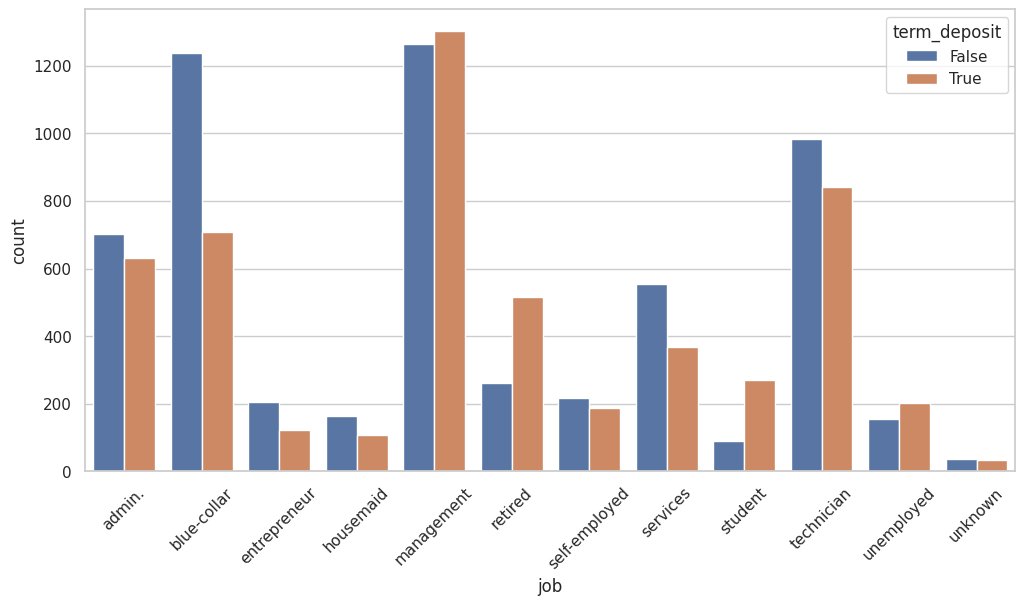

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='job',
    hue='term_deposit',
    data=bank_df
)

plt.xticks(rotation=45)

plt.show()

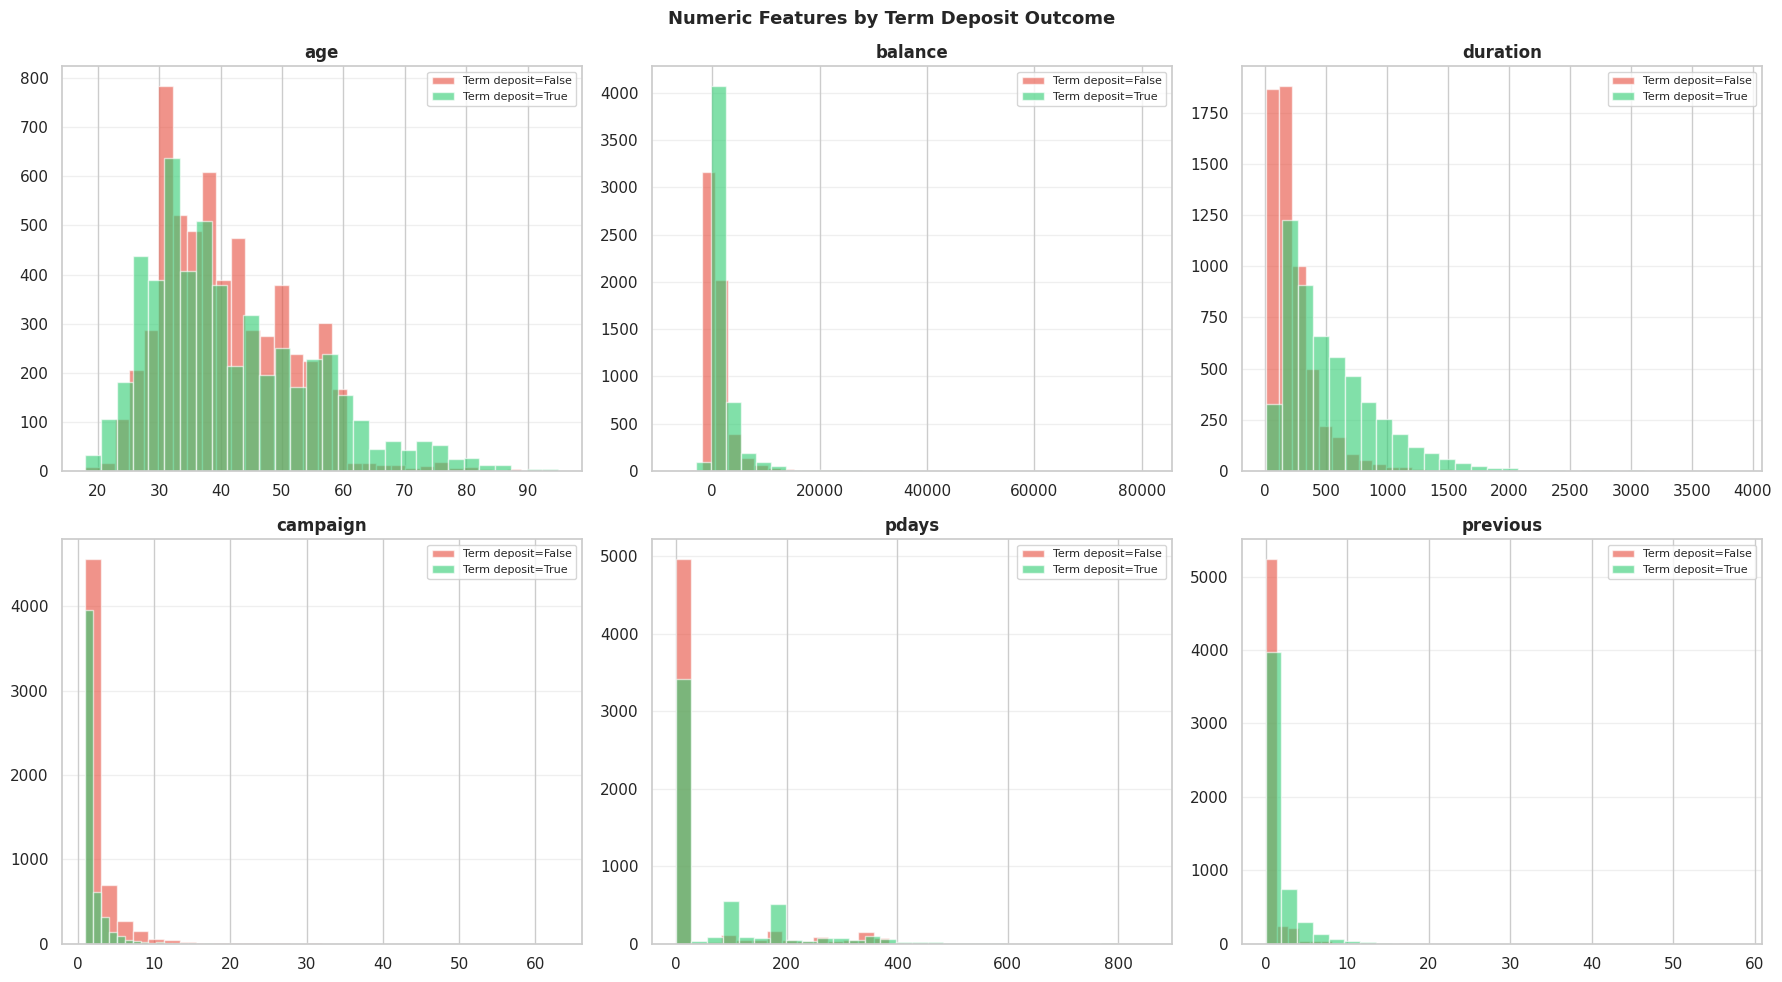

In [17]:
# Numeric Feature Distributions by Target
num_cols = ['age','balance','duration','campaign','pdays','previous']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Numeric Features by Term Deposit Outcome", fontsize=13, fontweight='bold')

colors = {True:'#2ECC71', False:'#E74C3C'}
for ax, col in zip(axes.flatten(), num_cols):
    for val, grp in bank_df.groupby('term_deposit'):
        ax.hist(grp[col], bins=30, alpha=0.6, label=f'Term deposit={val}',
                color=colors[val], density=False, edgecolor='white', lw=0.3)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("02_numeric_dist.png", dpi=150, bbox_inches='tight')
plt.show()

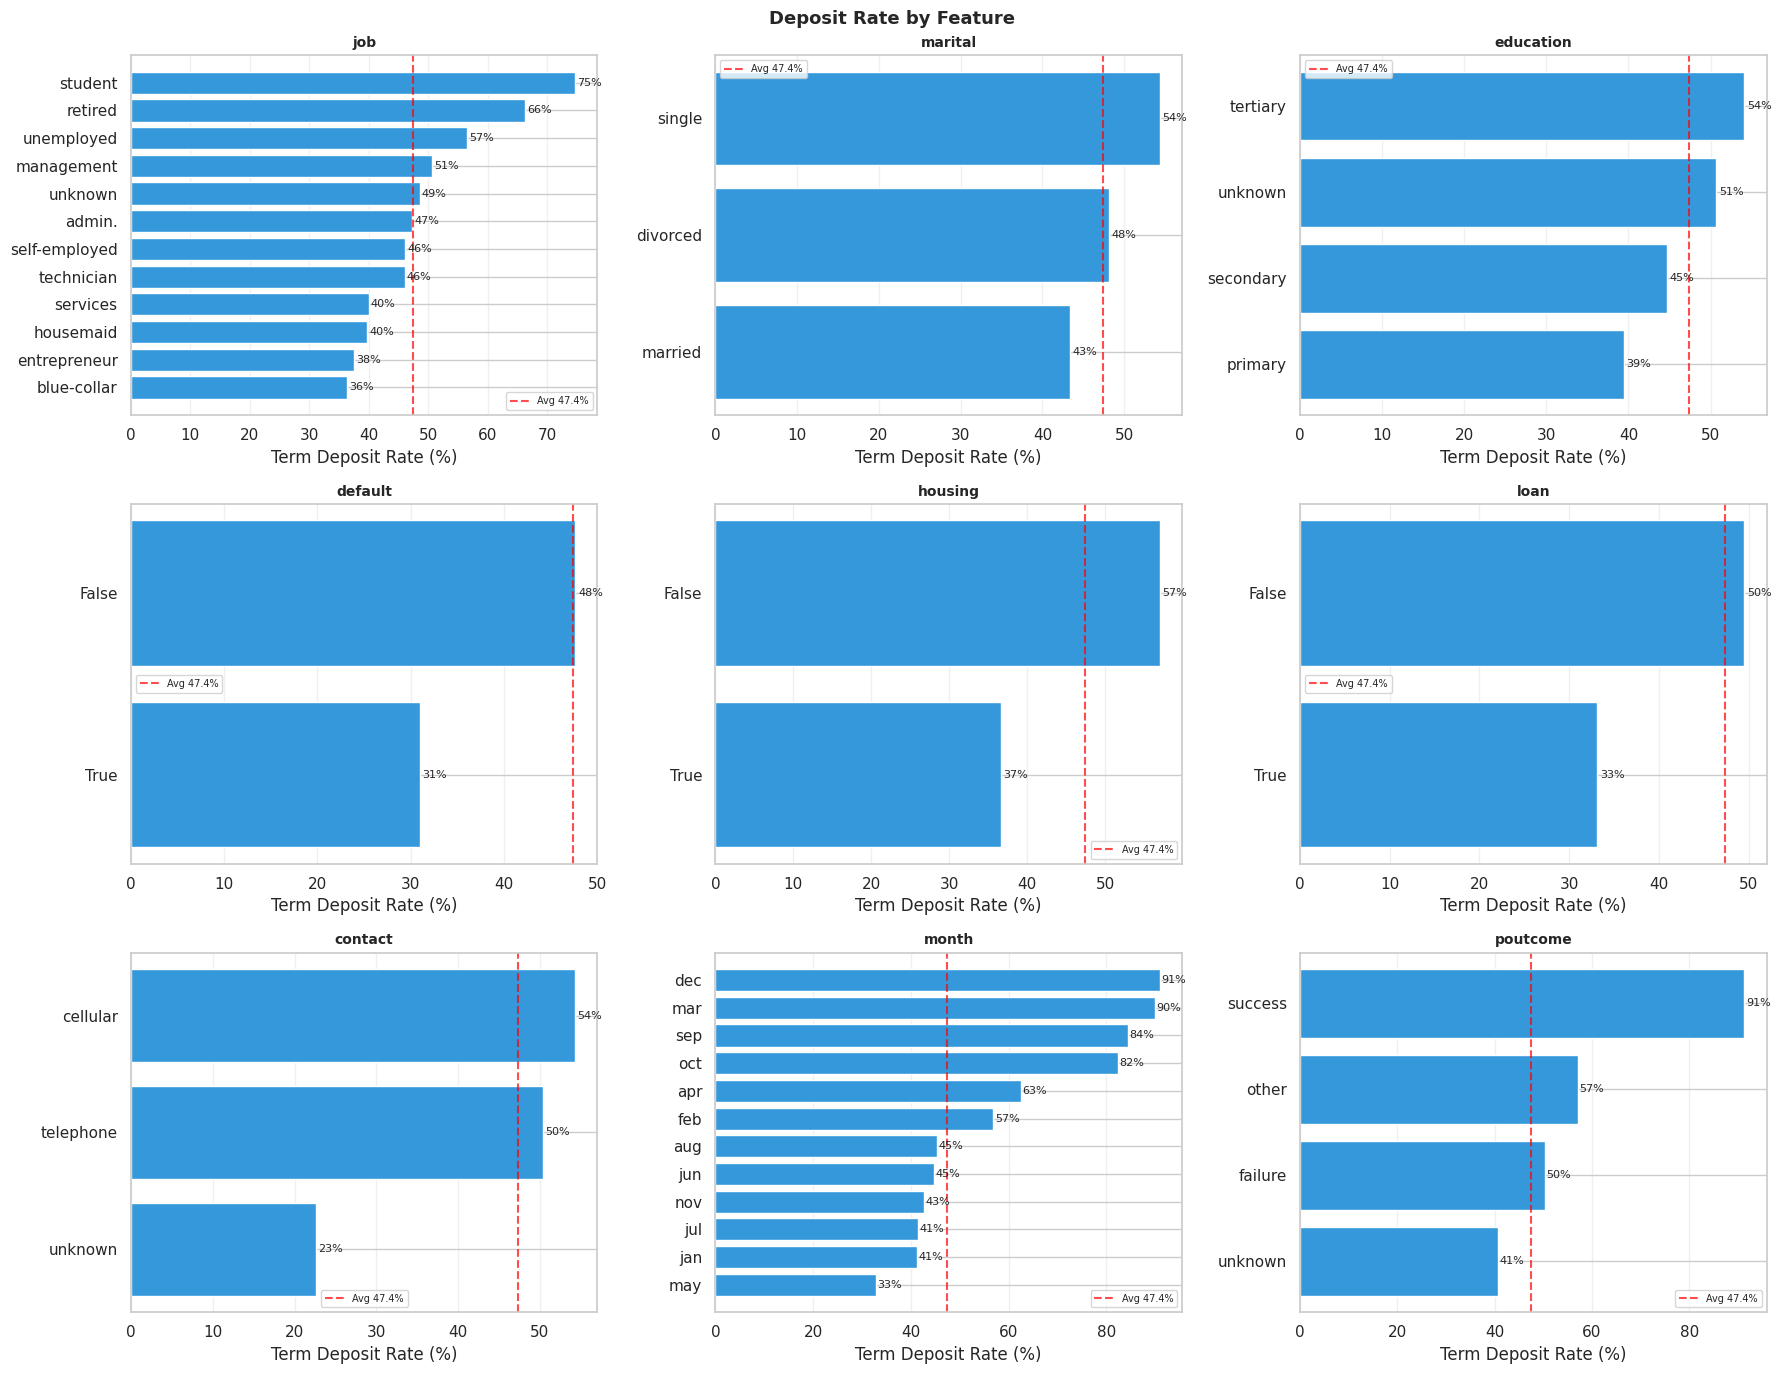

In [18]:
# Define Categorical & Boolean Feature Deposit Rates
cat_cols = ['job','marital','education','default','housing','loan',
            'contact','month','poutcome']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Deposit Rate by Feature", fontsize=13, fontweight='bold')

# 1. Calculate overall rate using boolean True (Global average subscription rate)
overall_rate = (bank_df['term_deposit'] == True).mean() * 100

# Loop through each subplot and feature simultaneously
for ax, col in zip(axes.flatten(), cat_cols):
    # 2. Calculate conversion percentage for each unique category within the feature
    ct = bank_df.groupby(col)['term_deposit'].apply(
        lambda x: (x == True).sum() / len(x) * 100).reset_index()

    # Format and sort the data from lowest to highest conversion rate
    ct.columns = [col, 'conversion_rate']
    ct = ct.sort_values('conversion_rate')

    # 3.  Convert the Y-axis values to strings!
    # This safely converts True/False into 'True'/'False' text so to avoid plotting boolean datatypes on the chart that plots between 0 and 1 and not the actual labels
    y_labels = ct[col].astype(str)

    # Draw horizontal bars based on the calculated subscription rate
    bars = ax.barh(y_labels, ct['conversion_rate'], color='#3498DB', edgecolor='white')

    # Add a vertical dashed red line representing the bank's overall average rate
    ax.axvline(overall_rate, color='red', ls='--', alpha=0.7, label=f'Avg {overall_rate:.1f}%')

    # Label the specific subplot
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel("Term Deposit Rate (%)")

    # Annotate the percentage at the tip of each horizontal bar
    for b, v in zip(bars, ct['conversion_rate']):
        ax.text(v + 0.3, b.get_y() + b.get_height()/2, f'{v:.0f}%', va='center', fontsize=8)

    # Display the legend and add soft vertical grid lines
    ax.legend(fontsize=7)
    ax.grid(axis='x', alpha=0.3)

# Adjust padding between plots, save as a high-res image, and display the chart
plt.tight_layout()
plt.savefig("03_cat_rates.png", dpi=150, bbox_inches='tight')
plt.show()

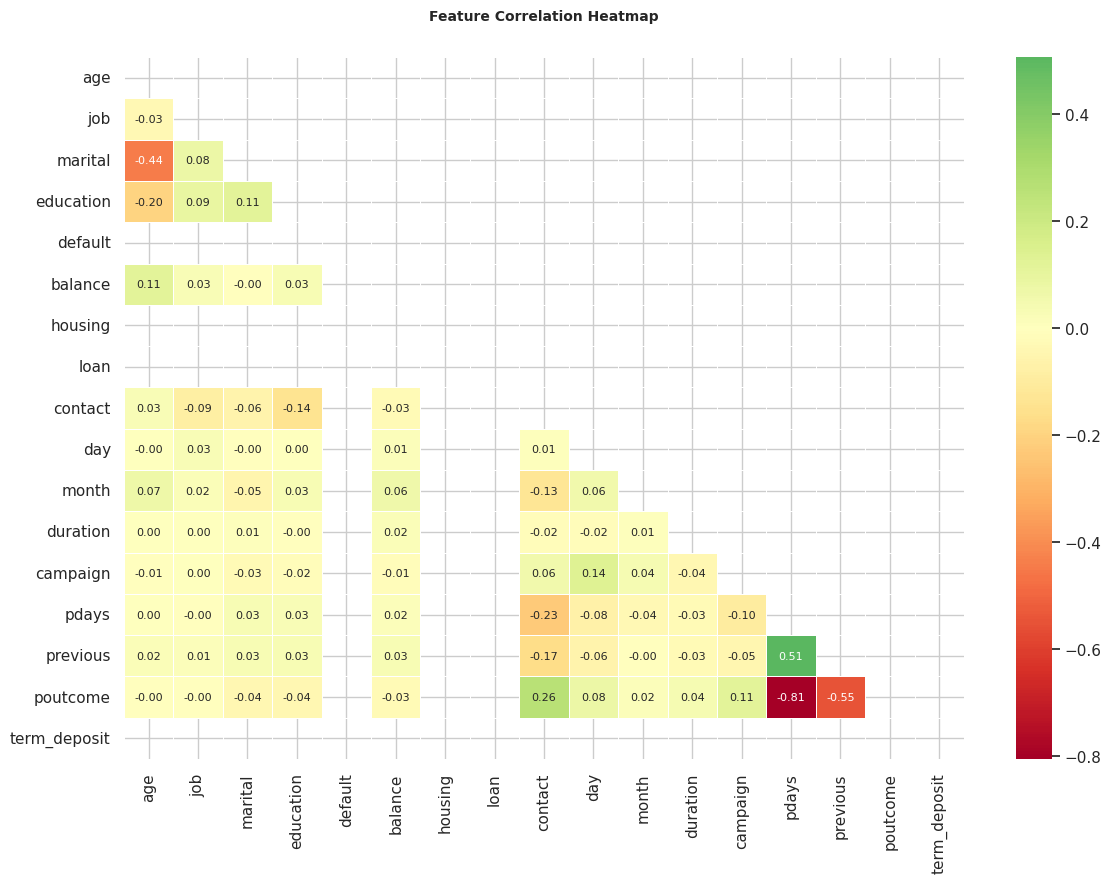

In [19]:
# Correlation Heatmap - Correct encoding as per column type

bank_df_enc = bank_df.copy()


# Binary - meaningful 0/1 mapping
for col in ['default', 'housing', 'loan']:
    bank_df_enc[col] = bank_df_enc[col].map({'yes': 1 , 'no': 0})

# Target variable - Binary
bank_df_enc['term_deposit'] = bank_df_enc['term_deposit'].map({'yes': 1, 'no': 0})

# Ordinal eduaction column - primary < secondary < tertiary (unknown = no info =0)
bank_df_enc['education'] = bank_df_enc['education'].map({'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3})

# Month - calender order 1-12 (approximate , good enough for heatmap)
month_order = {'jan':1, 'feb':2 , 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}

bank_df_enc['month'] = bank_df_enc['month'].map(month_order)


# Nominal columns - LabelEncoder only for Heatmap
# job, marital, contact, poutcome have NO natural order
# Correlations involving these four should be read as "rough signal only"

nominal_cols = ['job', 'marital', 'contact', 'poutcome']

for col in nominal_cols:
    bank_df_enc[col] = LabelEncoder().fit_transform(bank_df_enc[col].astype(str))

# Plot heatmap
plt.figure(figsize=(12,9))
mask = np.triu(np.ones_like(bank_df_enc.corr(), dtype=bool))
sns.heatmap(bank_df_enc.corr(), annot = True, fmt = '.2f' , mask = mask, cmap='RdYlGn', center=0, linewidth=0.5, annot_kws={'size': 8})

# Set the title of the Heatmap Plot
plt.title("Feature Correlation Heatmap\n", fontsize=10, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("04_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

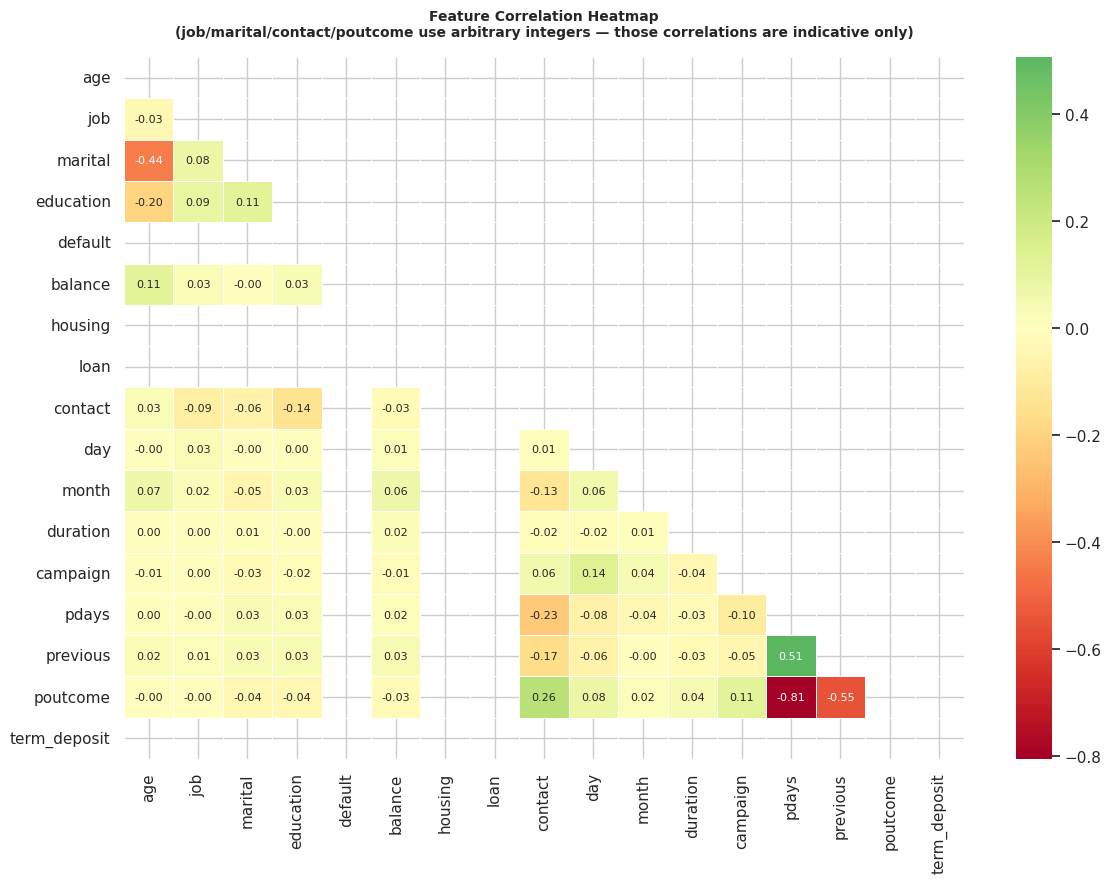

In [ ]:
# 3.5 Correlation Heatmap — correct encoding per column type
# ──────────────────────────────────────────────────────────────────────────────
# IMPORTANT: Each column is encoded based on its TRUE nature, not convenience.
#
#   Binary    (2 values, no order) → map yes=1, no=0
#   Ordinal   (clear ranked order) → integer map respecting the rank
#   Nominal   (no order, >2 vals)  → LabelEncoder integers FOR HEATMAP ONLY
#                                     (numbers are arbitrary — treat those
#                                      correlations as rough, not precise)
#   Cyclical  (wraps around)       → numeric 1-12 is good enough for heatmap
# ──────────────────────────────────────────────────────────────────────────────
bank_df_enc = bank_df.copy()

# Binary — meaningful 0/1 mapping
for col in ['default', 'housing', 'loan']:
    bank_df_enc[col] = bank_df_enc[col].map({'yes': 1, 'no': 0})

# Target — binary
bank_df_enc['term_deposit'] = bank_df_enc['term_deposit'].map({'yes': 1, 'no': 0})

# Ordinal education — primary < secondary < tertiary (unknown = no info = 0)
bank_df_enc['education'] = bank_df_enc['education'].map(
    {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
)

# Month — calendar order 1-12 (approximate, good enough for heatmap)
month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
               'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
bank_df_enc['month'] = bank_df_enc['month'].map(month_order)

# Nominal columns — LabelEncoder ONLY for heatmap (arbitrary integers)
# job, marital, contact, poutcome have NO natural order
# Correlations involving these four should be read as "rough signal only"
nominal_cols = ['job', 'marital', 'contact', 'poutcome']
for col in nominal_cols:
    bank_df_enc[col] = LabelEncoder().fit_transform(bank_df_enc[col].astype(str))

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(bank_df_enc.corr(), dtype=bool))
sns.heatmap(bank_df_enc.corr(), annot=True, fmt='.2f', mask=mask,
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title(
    "Feature Correlation Heatmap\n"
    "(job/marital/contact/poutcome use arbitrary integers — those correlations are indicative only)",
    fontsize=10, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig("04_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 3.6 EDA Summary
print("""
KEY EDA FINDINGS
==========================================================
1. DURATION is the strongest predictor — longer call = genuine
   interest = YES. NOTE: exclude at inference time in production
   (you only know duration AFTER the call, not before).
2. POUTCOME=success -> ~65% conversion rate (best historical feature)
3. Seasonality: Mar/Sep/Oct/Dec campaigns outperform May/Jun/Aug
4. RETIRED clients have much higher deposit acceptance rate
5. CELLULAR contact significantly outperforms TELEPHONE
6. HIGH BALANCE customers show better propensity to invest
7. TOO MANY CONTACTS (campaign > 5) reduces conversion — fatigue
8. Dataset is balanced (47% yes / 53% no) — no SMOTE needed
==========================================================""")


KEY EDA FINDINGS
1. DURATION is the strongest predictor — longer call = genuine
   interest = YES. NOTE: exclude at inference time in production
   (you only know duration AFTER the call, not before).
2. POUTCOME=success -> ~65% conversion rate (best historical feature)
3. Seasonality: Mar/Sep/Oct/Dec campaigns outperform May/Jun/Aug
4. RETIRED clients have much higher deposit acceptance rate
5. CELLULAR contact significantly outperforms TELEPHONE
6. HIGH BALANCE customers show better propensity to invest
7. TOO MANY CONTACTS (campaign > 5) reduces conversion — fatigue
8. Dataset is balanced (47% yes / 53% no) — no SMOTE needed


In [24]:
# def feature_engineering(df):
#     d = df.copy()

#     # ── Target ────────────────────────────────────────────────────────────────
#     d['deposit_binary'] = (d['deposit'] == 'yes').astype(int)

#     # ── Age segments (nominal bucket — no order between groups) ───────────────
#     d['age_group'] = pd.cut(d['age'],
#                              bins=[0, 25, 35, 45, 55, 65, 100],
#                              labels=['<25','25-35','35-45','45-55','55-65','65+'])

#     # ── Balance features ──────────────────────────────────────────────────────
#     # balance is right-skewed with negatives — log1p of clipped positives
#     d['balance_log']      = np.log1p(np.clip(d['balance'], 0, None))
#     d['has_negative_bal'] = (d['balance'] < 0).astype(int)
#     d['balance_bucket']   = pd.qcut(d['balance'], q=5,
#                                      labels=['Q1','Q2','Q3','Q4','Q5'],
#                                      duplicates='drop')

#     # ── Campaign fatigue features ─────────────────────────────────────────────
#     d['campaign_log']     = np.log1p(d['campaign'])
#     d['is_first_contact'] = (d['campaign'] == 1).astype(int)
#     d['many_contacts']    = (d['campaign'] > 5).astype(int)

#     # ── Prior contact features ────────────────────────────────────────────────
#     d['was_contacted_prev'] = (d['pdays'] != -1).astype(int)
#     d['days_since_contact'] = d['pdays'].replace(-1, 999)   # 999 = never contacted
#     d['has_previous']       = (d['previous'] > 0).astype(int)

#     # ── Duration features ─────────────────────────────────────────────────────
#     d['duration_min']    = d['duration'] / 60
#     d['duration_bucket'] = pd.cut(d['duration'],
#                                    bins=[0, 60, 180, 360, 600, 99999],
#                                    labels=['very_short','short','medium','long','very_long'])

#     # ── Seasonality — cyclical month encoding ─────────────────────────────────
#     # month is CYCLICAL: December and January are adjacent, not 11 apart.
#     # sin/cos encoding preserves this circular distance correctly.
#     # This is better than raw 1-12 for linear models; trees don't care.
#     month_num_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
#                      'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
#     d['month_num'] = d['month'].map(month_num_map)
#     d['month_sin'] = np.sin(2 * np.pi * d['month_num'] / 12)
#     d['month_cos'] = np.cos(2 * np.pi * d['month_num'] / 12)

#     # Quarter (nominal bucket — no rank across quarters for this use case)
#     d['quarter'] = d['month_num'].apply(
#         lambda m: 'Q1' if m <= 3 else 'Q2' if m <= 6 else 'Q3' if m <= 9 else 'Q4'
#     )
#     d['is_end_of_year'] = d['month'].isin(['oct','nov','dec']).astype(int)

#     # ── Financial stress proxy ────────────────────────────────────────────────
#     d['financial_stress'] = (
#         (d['default'] == 'yes').astype(int) +
#         (d['loan']    == 'yes').astype(int) +
#         (d['housing'] == 'yes').astype(int)
#     )

#     # ── Interaction features ──────────────────────────────────────────────────
#     d['age_x_balance'] = d['age'] * d['balance_log']
#     d['retired_flag']  = (d['job'] == 'retired').astype(int)
#     d['student_flag']  = (d['job'] == 'student').astype(int)

#     return d

# df_fe = feature_engineering(df)
# new_feats = [c for c in df_fe.columns if c not in df.columns]
# print(f"New features ({len(new_feats)}): {new_feats}")

In [25]:
def feature_engineering(bank_df):
    d = bank_df.copy()


    # ----Target----------------------------------------------------------------
    d['term_deposit_binary']= (d['term_deposit'] == True).astype(int)

    # ---- Age segments (nominal bucket - no order between the groups )---------
    d['age_group'] = pd.cut(d['age'],
             bins = [0, 25, 35, 45, 55, 65, 100],
             labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+'], right = False )  # eg) for bin [0-25] --> It include 0 upto 25 , but when choosen right = False then include 0 upto 24

    # ---- Balance Feature -----------------------------------------------------
    # balance is right-skewed with negatives
    d['balance_log'] = np.log1p(np.clip(d['balance'],0,None))
    d['has_negative_bal'] = (d['balance'] < 0).astype(int)  # Indicates the negative bank balance to 1 .
    d['balance_bucket'] = pd.qcut(d['balance'], q = 5, labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates = 'drop')

    # ---- Campaign fatigue features -------------------------------------------
    d['campaign_log']= np.log1p(d['campaign'])
    d['is_first_contact'] = (d['campaign'] == 1).astype(int)
    d['many_contacts'] = (d['campaign'] > 5).astype(int)

    # ---- Prior contact feature -----------------------------------------------
    d['was_contacted_prev'] = (d['pdays'] != -1).astype(int)
    d['days_since_contact'] = d['pdays'].replace(-1,999)  # 999 = never contacted
    d['has_previous'] = (d['previous'] > 0).astype(int)

    # --- Duration features ----------------------------------------------------
    d['duration_min'] = d['duration'] / 60 # converts the call in sec to min
    d['duration_bucket'] = pd.cut(d['duration'],
                                  bins = [0, 60, 180, 360, 600, 99999],
                                  labels = ['very_short', 'short', 'medium', 'long', 'very_long'])

    # ── Seasonality — cyclical month encoding ─────────────────────────────────
    # month is CYCLICAL: December and January are adjacent, not 11 apart.
    # sin/cos encoding preserves this circular distance correctly.
    # This is better than raw 1-12 for linear models.
    month_num_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                     'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    d['month_num'] = d['month'].map(month_num_map)
    d['month_sin'] = np.sin(2 * np.pi * d['month_num'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month_num'] / 12)

    # Quater ( Nominal bucket - no rank accross quaters )
    d['quarter'] = d['month_num'].apply(
        lambda m: 'Q1' if m <= 3 else 'Q2' if m<= 6 else 'Q3' if m <= 9 else 'Q4'
    )
    d['is_end_of_year'] = d['month'].isin(['oct','nov','dec']).astype(int)

    # ---- Financial stress check ----------------------------------------------
    d['financial_stress'] = (
        (d['default'] == True).astype(int) +
        (d['loan'] == True).astype(int) +
        (d['housing'] == True).astype(int)
    )

    # Interaction features -----------------------------------------------------

    d['age_x_balance'] = d['age'] * d['balance_log']
    d['retired_flag']  = (d['job'] == 'retired').astype(int)
    d['student_flag']  = (d['job'] == 'student').astype(int)

    return d


bank_df_fe = feature_engineering(bank_df)
new_feats = [c for c in bank_df_fe.columns if c not in bank_df.columns]
print(f"New features({len(new_feats)}): {new_feats}")



New features(22): ['term_deposit_binary', 'age_group', 'balance_log', 'has_negative_bal', 'balance_bucket', 'campaign_log', 'is_first_contact', 'many_contacts', 'was_contacted_prev', 'days_since_contact', 'has_previous', 'duration_min', 'duration_bucket', 'month_num', 'month_sin', 'month_cos', 'quarter', 'is_end_of_year', 'financial_stress', 'age_x_balance', 'retired_flag', 'student_flag']


In [35]:
def encode_features(bank_df_fe):
    """
    Encode every column according to its true statistical type.

    COLUMN-BY-COLUMN DECISIONS:

    job        : NOMINAL  — 12 job types, no natural rank between them.
                            Encoding as 0-11 would imply 'technician > admin'
                            numerically, which is wrong. Use OHE.

    marital    : NOMINAL  — divorced/married/single have no ordered relationship.
                            Use OHE.

    education  : ORDINAL  — primary < secondary < tertiary is a clear, meaningful
                            rank. Map to 0/1/2/3. 'unknown' gets 0 (missing info).

    default    : BINARY   — yes/no, two values only. Map 1/0.

    housing    : BINARY   — yes/no. Map 1/0.

    loan       : BINARY   — yes/no. Map 1/0.

    contact    : NOMINAL  — cellular/telephone/unknown are channel types with no
                            inherent order. Use OHE.

    month      : CYCLICAL — already encoded as sin+cos in feature_engineering().
                            Drop the raw string 'month' here.

    poutcome   : NOMINAL  — failure/success/other/unknown. Success > failure
                            directionally but 'other' and 'unknown' break any
                            clean ordinal sequence. Safer to use OHE.

    age_group  : NOMINAL BUCKET  — created via pd.cut with string labels, OHE.
    balance_bucket : NOMINAL BUCKET — same, OHE.
    duration_bucket: NOMINAL BUCKET — same, OHE.
    quarter    : NOMINAL BUCKET — same, OHE.

    drop_first=True on all OHE:
        Removes one dummy per group to prevent perfect multicollinearity.

    """
    d = bank_df_fe.copy()

    # ---- Binary columns ------------------------------------------------------
    for col in ['default', 'housing', 'loan']:
        d[col] = d[col].map({'yes': 1, 'no':0})

    # ---- Ordinal : education -------------------------------------------------
    d['education'] = df['education'].map(
        {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
    )

    # ---- Nominal : One-Hot encoding (with drop_first = True to avoid multicollinearity)
    ohe_cols = [
        'job',              # 12 categories -> 11 dummies after drop_first
        'marital',          # 3  categories -> 2  dummies
        'contact',          # 4  categories -> 3  dummies
        'poutcome',         # 4  categories -> 3  dummies
        'age_group',        # 6  categories -> 5  dummies
        'balance_bucket',   # 5  categories -> 4  dummies
        'duration_bucket',  # 5  categories -> 4  dummies
        'quarter'           # 4  categories -> 3  dummies

    ]

    d= pd.get_dummies(d, columns = ohe_cols, drop_first = True)

    # ---- drop columns no longer needed ---------------------------------------
    # 'term_deposit'   -> target already captured as term_deposit_binary
    # 'day'       -> low signal, too granular
    # 'month'     -> replaced by month_sin, month_cos, is_end_of_year, quarter
    # 'month_num' -> raw integer already absorbed into sin/cos
    drop_cols = ['term_deposit', 'day', 'month', 'month_num']
    d = d.drop(columns = [c for c in drop_cols if c in d.columns])


    # ---- Bool to int conversion ----------------------------------------------

    bool_cols = d.select_dtypes(include = 'bool').columns
    d[bool_cols] = d[bool_cols].astype(int)

    return d

bank_df_model = encode_features(bank_df_fe)
bank_df_model = bank_df_model.dropna()

print(f"Model DataFrame shape : {bank_df_model.shape}")
print(f"Features after encoding : {bank_df_model.shape[1] - 1}")
print()

# Show the feature groups so we know what was created
feat_cols = [c for c in bank_df_model if c != 'term_deposit_binary']
print("Sample encoded features:")

for prefix in ['job_', 'marital_', 'contact_', 'poutcome_', 'education', 'month_sin', 'month_cos']:
    matched = [c for c in feat_cols if c.startswith(prefix)]
    if matched:
        print(f"  {prefix:<20} --> {matched}")



Model DataFrame shape : (0, 61)
Features after encoding : 60

Sample encoded features:
  job_                 --> ['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown']
  marital_             --> ['marital_married', 'marital_single']
  contact_             --> ['contact_telephone', 'contact_unknown']
  poutcome_            --> ['poutcome_other', 'poutcome_success', 'poutcome_unknown']
  education            --> ['education']
  month_sin            --> ['month_sin']
  month_cos            --> ['month_cos']


In [33]:
bank_df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 62 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        0 non-null      Int64  
 1   education                  0 non-null      int64  
 2   default                    0 non-null      float64
 3   balance                    0 non-null      Int64  
 4   housing                    0 non-null      float64
 5   loan                       0 non-null      float64
 6   duration                   0 non-null      Int64  
 7   campaign                   0 non-null      Int64  
 8   pdays                      0 non-null      Int64  
 9   previous                   0 non-null      Int64  
 10  term_deposit               0 non-null      int64  
 11  term_deposit_binary        0 non-null      int64  
 12  balance_log                0 non-null      Float64
 13  has_negative_bal           0 non-null      int64  
 14  campaign_lo

In [36]:
# def encode_features(bank_df_fe):
#     """
#     Encode every column according to its true statistical type.

#     COLUMN-BY-COLUMN DECISIONS:

#     job        : NOMINAL  — 12 job types, no natural rank between them.
#                             Encoding as 0-11 would imply 'technician > admin'
#                             numerically, which is wrong. Use OHE.

#     marital    : NOMINAL  — divorced/married/single have no ordered relationship.
#                             Use OHE.

#     education  : ORDINAL  — primary < secondary < tertiary is a clear, meaningful
#                             rank. Map to 0/1/2/3. 'unknown' gets 0 (missing info).

#     default    : BINARY   — yes/no, two values only. Map 1/0.

#     housing    : BINARY   — yes/no. Map 1/0.

#     loan       : BINARY   — yes/no. Map 1/0.

#     contact    : NOMINAL  — cellular/telephone/unknown are channel types with no
#                             inherent order. Use OHE.

#     month      : CYCLICAL — already encoded as sin+cos in feature_engineering().
#                             Drop the raw string 'month' here.

#     poutcome   : NOMINAL  — failure/success/other/unknown. Success > failure
#                             directionally but 'other' and 'unknown' break any
#                             clean ordinal sequence. Safer to use OHE.

#     age_group  : NOMINAL BUCKET  — created via pd.cut with string labels, OHE.
#     balance_bucket : NOMINAL BUCKET — same, OHE.
#     duration_bucket: NOMINAL BUCKET — same, OHE.
#     quarter    : NOMINAL BUCKET — same, OHE.

#     drop_first=True on all OHE:
#         Removes one dummy per group to prevent perfect multicollinearity.

#     """
#     d = bank_df_fe.copy()

#     # ── Binary columns ────────────────────────────────────────────────────────
#     for col in ['default', 'housing', 'loan']:
#         d[col] = d[col].map({'yes': 1, 'no': 0})

#     # ── Ordinal: education ────────────────────────────────────────────────────
#     d['education'] = d['education'].map(
#         {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3}
#     )

#     # ── Nominal: One-Hot Encoding (drop_first=True avoids multicollinearity) ──
#     ohe_cols = [
#         'job',             # 12 categories -> 11 dummies after drop_first
#         'marital',         # 3  categories -> 2  dummies
#         'contact',         # 3  categories -> 2  dummies
#         'poutcome',        # 4  categories -> 3  dummies
#         'age_group',       # 6  categories -> 5  dummies
#         'balance_bucket',  # 5  categories -> 4  dummies
#         'duration_bucket', # 5  categories -> 4  dummies
#         'quarter',         # 4  categories -> 3  dummies
#     ]
#     d = pd.get_dummies(d, columns=ohe_cols, drop_first=True)

#     # ── Drop columns no longer needed ─────────────────────────────────────────
#     # 'deposit'   -> target already captured as deposit_binary
#     # 'day'       -> low signal, too granular
#     # 'month'     -> replaced by month_sin, month_cos, is_end_of_year, quarter
#     # 'month_num' -> raw integer already absorbed into sin/cos
#     drop_cols = ['term_deposit', 'day', 'month', 'month_num']
#     d = d.drop(columns=[c for c in drop_cols if c in d.columns])

#     # ── Bool -> int ───────────────────────────────────────────────────────────
#     bool_cols = d.select_dtypes(include='bool').columns
#     d[bool_cols] = d[bool_cols].astype(int)

#     return d

# bank_df_model = encode_features(bank_df_fe)
# bank_df_model = bank_df_model.dropna()

# print(f"Model DataFrame shape : {bank_df_model.shape}")
# print(f"Features after encoding: {bank_df_model.shape[1] - 1}")
# print()

# # Show the feature groups so you know what was created
# feat_cols = [c for c in bank_df_model.columns if c != 'deposit_binary']
# print("Sample encoded features:")
# for prefix in ['job_','marital_','contact_','poutcome_','education','month_sin','month_cos']:
#     matched = [c for c in feat_cols if c.startswith(prefix)]
#     if matched:
#         print(f"  {prefix:<20} -> {matched}")

# bank_df_model.head(2)

# EDA

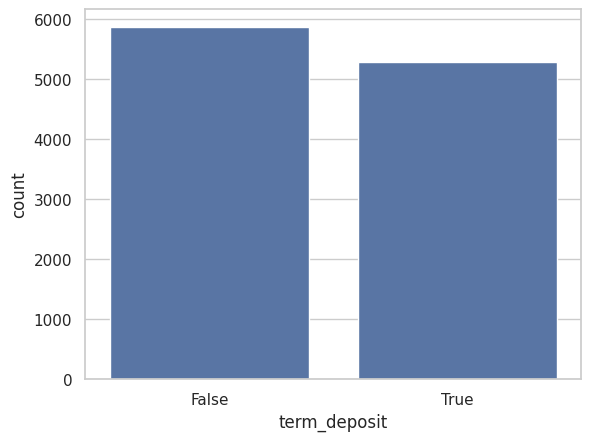

In [ ]:
 # Target Variable(loan_acceptance) Distribution visualization
 sns.countplot(x='term_deposit', data=bank_df)

 plt.show()

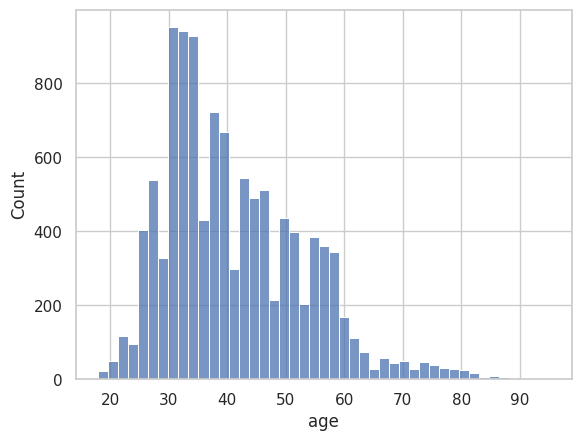

In [ ]:
# Plot Age Distribution
sns.histplot(bank_df['age'], bins=45)

plt.show()

In [ ]:
# Plot Balance Vs Loan Acceptance

sns.boxplot(
    x='loan_acceptance',
    y='balance',
    data=df
)

In [ ]:
sns.boxplot(x="loan_acceptance", y="balance", data=df, showfliers=False)
# 'showfliers=False' completely hides the outlier points

# Alternatively, manually set limits to zoom in, e.g., -$5,000 to $20,000:
# plt.ylim(-5000, 20000)

plt.title("Balance Distribution (Outliers Hidden)")
plt.show()

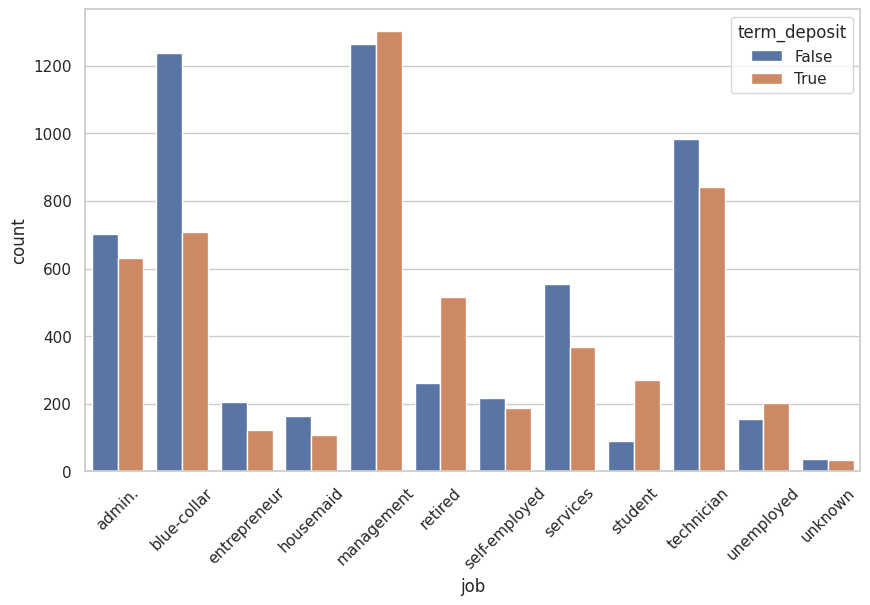

In [ ]:
# Job wise Analysis

plt.figure(figsize=(10,6))

sns.countplot(x='job', hue='term_deposit', data=bank_df)
plt.xticks(rotation =45)
plt.show()

# Data Preprocessing

In [ ]:
# Encode Target Variable (loan_acceptance)

df['loan_acceptance'] = df['loan_acceptance'].map({'yes':1, 'no':0})

In [ ]:
# ─── 3.1 Basic Profiling ──────────────────────────────────────────────────────
print('='*60)
print('SHAPE:', df.shape)
print('='*60)
print('\nDATA TYPES:\n', df.dtypes)
print('\nMISSING VALUES (%):\n',
      (df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False))
print('\nDUPLICATES:', df.duplicated().sum())

In [ ]:
# ─── 3.2 Descriptive Statistics ───────────────────────────────────────────────
print('NUMERICAL STATS:')
display(df.describe().T.style.background_gradient(cmap='Blues'))

In [ ]:
print('CATEGORICAL STATS:')
display(df.describe(include='object').T)


In [ ]:


plt.figure(figsize=(14,10))


sns.heatmap(
    bank_df.corr(),
    cmap='coolwarm'
)

plt.show()

NameError: name 'plt' is not defined

# New Approach check